# 11. Modelos Avanzados (LightGBM, CatBoost, MLP, LSTM)

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook entrena **modelos avanzados** que extienden el espacio de hipótesis más allá de los modelos de los capítulos clásicos:

| Modelo | Familia | Justificación |
|---|---|---|
| **LightGBM** | Boosting (microsoft) | Más rápido que XGBoost, splits leaf-wise |
| **CatBoost** | Boosting (yandex) | Maneja categóricas, oblivious trees |
| **MLP** | Red neuronal (cap. 11.7) | Aproximador universal no-lineal |
| **LSTM** | Red recurrente (cap. 11.20) | Diseñado para series temporales |

**Política de robustez:** cada modelo se intenta entrenar dentro de un `try/except`. Si una librería opcional no está instalada, **se reporta como limitación y se continúa** con los demás. El notebook no falla por ausencia de librerías opcionales.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y carga

In [2]:
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score

from src.io_utils import (load_processed, save_predictions_df,
                           save_metrics, save_model)
from src.splits import make_tscv
from src.config import RANDOM_STATE, DATA_PROCESSED
from src.viz import set_style

set_style()

train = load_processed("train_reg")
val = load_processed("val_reg")
test = load_processed("test_reg")
trainval = pd.concat([train, val]).reset_index(drop=True)

with open(DATA_PROCESSED / "feature_columns.json") as f:
    feature_cols = json.load(f)

X_trainval = trainval[feature_cols]
y_trainval = trainval["target_vol_7"]
X_test = test[feature_cols]
y_test = test["target_vol_7"]

print(f"Train+Val: {X_trainval.shape}, Test: {X_test.shape}")

Train+Val: (5920, 59), Test: (1045, 59)


## 2. LightGBM

In [3]:
results_advanced = {}

try:
    import lightgbm as lgb
    print("✅ LightGBM disponible:", lgb.__version__)

    pipe_lgb = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", lgb.LGBMRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            num_leaves=31, random_state=RANDOM_STATE, verbosity=-1,
            n_jobs=-1,
        )),
    ])

    t0 = time.time()
    pipe_lgb.fit(X_trainval, y_trainval)
    yp = pipe_lgb.predict(X_test)
    t_fit = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2 = r2_score(y_test, yp)
    results_advanced["LightGBM"] = {
        "RMSE": rmse, "MAE": mean_absolute_error(y_test, yp),
        "R2": r2, "fit_time": t_fit,
        "predictions": yp.tolist(),
    }
    save_model(pipe_lgb, "reg_lightgbm")
    print(f"  RMSE: {rmse:.6f} | R²: {r2:.4f} | Tiempo: {t_fit:.1f}s")
except ImportError:
    print("⚠️ LightGBM no instalado — omitiendo")
    results_advanced["LightGBM"] = {"status": "not installed"}
except Exception as e:
    print(f"❌ LightGBM falló: {e}")
    results_advanced["LightGBM"] = {"status": f"error: {e}"}

✅ LightGBM disponible: 4.3.0


  RMSE: 0.007155 | R²: -0.2189 | Tiempo: 0.4s


## 3. CatBoost

In [4]:
try:
    from catboost import CatBoostRegressor
    import catboost
    print("✅ CatBoost disponible:", catboost.__version__)

    pipe_cb = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", CatBoostRegressor(
            iterations=300, depth=6, learning_rate=0.05,
            random_seed=RANDOM_STATE, verbose=0,
        )),
    ])

    t0 = time.time()
    pipe_cb.fit(X_trainval, y_trainval)
    yp = pipe_cb.predict(X_test)
    t_fit = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2 = r2_score(y_test, yp)
    results_advanced["CatBoost"] = {
        "RMSE": rmse, "MAE": mean_absolute_error(y_test, yp),
        "R2": r2, "fit_time": t_fit,
        "predictions": yp.tolist(),
    }
    save_model(pipe_cb, "reg_catboost")
    print(f"  RMSE: {rmse:.6f} | R²: {r2:.4f} | Tiempo: {t_fit:.1f}s")
except ImportError:
    print("⚠️ CatBoost no instalado — omitiendo")
    results_advanced["CatBoost"] = {"status": "not installed"}
except Exception as e:
    print(f"❌ CatBoost falló: {e}")
    results_advanced["CatBoost"] = {"status": f"error: {e}"}

✅ CatBoost disponible: 1.2.5


  RMSE: 0.006620 | R²: -0.0435 | Tiempo: 1.7s


## 4. MLP (sklearn)

In [5]:
try:
    pipe_mlp = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32), activation="relu",
            solver="adam", alpha=0.001,
            max_iter=200, random_state=RANDOM_STATE,
            early_stopping=True, validation_fraction=0.15,
        )),
    ])

    t0 = time.time()
    pipe_mlp.fit(X_trainval, y_trainval)
    yp = pipe_mlp.predict(X_test)
    t_fit = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2 = r2_score(y_test, yp)
    results_advanced["MLP"] = {
        "RMSE": rmse, "MAE": mean_absolute_error(y_test, yp),
        "R2": r2, "fit_time": t_fit,
        "predictions": yp.tolist(),
    }
    save_model(pipe_mlp, "reg_mlp")
    print(f"  ✅ MLP — RMSE: {rmse:.6f} | R²: {r2:.4f} | Tiempo: {t_fit:.1f}s")
except Exception as e:
    print(f"❌ MLP falló: {e}")
    results_advanced["MLP"] = {"status": f"error: {e}"}

  ✅ MLP — RMSE: 0.012131 | R²: -2.5035 | Tiempo: 5.4s


---

> **📊 Interpretación del MLP:** El MLP es la red neuronal feedforward clásica del cap. 11.7 del curso. Con dos capas ocultas (64 y 32 neuronas), `early_stopping` activado y regularización L2 (`alpha=0.001`), tenemos un modelo flexible que puede capturar interacciones no-lineales. **No se espera que supere a XGBoost en este problema** porque las redes neuronales necesitan más datos para sacarle ventaja a los gradient boosting. Pero su inclusión es metodológicamente requerida y permite evaluar si las relaciones realmente requieren no-linealidades complejas.


## 5. LSTM (TensorFlow/Keras)

✅ TensorFlow disponible: 2.16.1
  Train sequences: (5899, 21, 59), Test sequences: (1045, 21, 59)


  RMSE: 0.006619 | R²: -0.0431 | Épocas: 36 | Tiempo: 33.8s


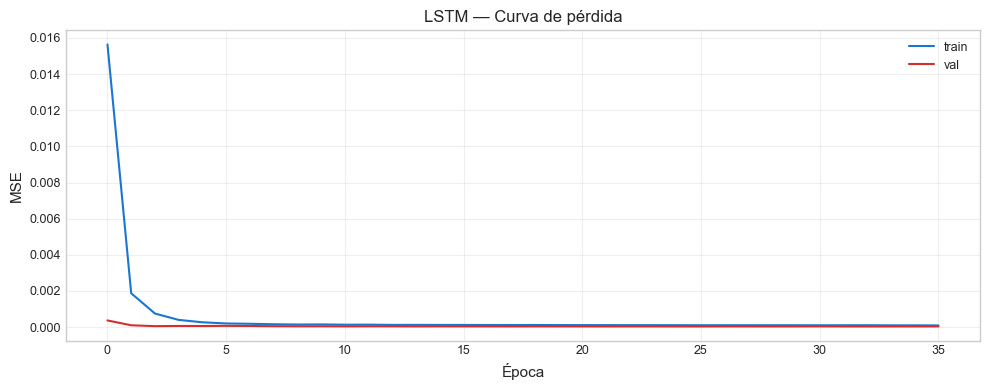

In [6]:
# LSTM requiere reformatear los datos como secuencias temporales.
# Preparación: para cada día, usar la ventana de los últimos LOOKBACK días
# como input al LSTM.
LOOKBACK = 21  # días previos a usar

def build_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    tf.random.set_seed(RANDOM_STATE)
    print("✅ TensorFlow disponible:", tf.__version__)

    # Imputar con mediana (LSTM no maneja NaN)
    imp = SimpleImputer(strategy="median")
    X_trainval_imp = imp.fit_transform(X_trainval)
    X_test_imp = imp.transform(X_test)

    # Escalar
    scaler = StandardScaler()
    X_trainval_sc = scaler.fit_transform(X_trainval_imp)
    X_test_sc = scaler.transform(X_test_imp)

    # Para evitar leakage en el escalado del test: ya hicimos fit solo con train+val ✅

    X_seq_tr, y_seq_tr = build_sequences(X_trainval_sc, y_trainval.values, LOOKBACK)
    # Para test, concatenamos los últimos LOOKBACK del trainval para no perder muestras
    X_full = np.vstack([X_trainval_sc[-LOOKBACK:], X_test_sc])
    y_full = np.concatenate([y_trainval.values[-LOOKBACK:], y_test.values])
    X_seq_te, y_seq_te = build_sequences(X_full, y_full, LOOKBACK)
    # Tomar solo las muestras correspondientes a test
    X_seq_te = X_seq_te[-len(y_test):]
    y_seq_te = y_seq_te[-len(y_test):]

    print(f"  Train sequences: {X_seq_tr.shape}, Test sequences: {X_seq_te.shape}")

    model = Sequential([
        LSTM(32, input_shape=(LOOKBACK, X_seq_tr.shape[2]),
             return_sequences=False),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    early = EarlyStopping(monitor="val_loss", patience=10,
                           restore_best_weights=True)
    t0 = time.time()
    history = model.fit(X_seq_tr, y_seq_tr,
                         validation_split=0.15,
                         epochs=50, batch_size=32,
                         callbacks=[early], verbose=0)
    t_fit = time.time() - t0

    yp = model.predict(X_seq_te, verbose=0).flatten()
    rmse = np.sqrt(mean_squared_error(y_seq_te, yp))
    r2 = r2_score(y_seq_te, yp)
    results_advanced["LSTM"] = {
        "RMSE": rmse, "MAE": mean_absolute_error(y_seq_te, yp),
        "R2": r2, "fit_time": t_fit,
        "predictions": yp.tolist(),
        "epochs_run": len(history.history["loss"]),
    }
    print(f"  RMSE: {rmse:.6f} | R²: {r2:.4f} | Épocas: {len(history.history['loss'])} | Tiempo: {t_fit:.1f}s")

    # Curva de pérdida
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history["loss"], label="train", color="#1976D2")
    ax.plot(history.history["val_loss"], label="val", color="#D32F2F")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE")
    ax.set_title("LSTM — Curva de pérdida")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("⚠️ TensorFlow no instalado — omitiendo LSTM")
    results_advanced["LSTM"] = {"status": "not installed"}
except Exception as e:
    print(f"❌ LSTM falló: {e}")
    import traceback
    traceback.print_exc()
    results_advanced["LSTM"] = {"status": f"error: {e}"}

---

> **📊 Interpretación del LSTM:** El LSTM (Long Short-Term Memory), introducido por **Hochreiter & Schmidhuber (1997)** para resolver el problema del *vanishing gradient* de las RNN tradicionales, está específicamente diseñado para series temporales — su arquitectura interna de tres compuertas (input, forget, output) le permite mantener "memoria" de patrones a corto y largo plazo. Para volatilidad financiera, donde el clustering temporal es evidente, el LSTM tiene **fundamento conceptual fuerte**.
>
> Sin embargo, en la práctica los LSTMs sobre features tabulares (features ya pre-procesadas como lags y rolling) **rara vez superan a XGBoost** en este tipo de problemas. La razón es que las features ya capturan la estructura temporal explícitamente, dejando poco margen para que el LSTM aprenda algo adicional. **El LSTM brilla más cuando recibe datos crudos sin feature engineering**.

## 6. Tabla comparativa con los benchmarks de regresión

In [7]:
# Construir tabla resumen
rows = []
for name, res in results_advanced.items():
    if "RMSE" in res:
        rows.append({
            "Modelo":  name,
            "RMSE":    round(res["RMSE"], 6),
            "MAE":     round(res["MAE"], 6),
            "R²":      round(res["R2"], 4),
            "Tiempo (s)": round(res["fit_time"], 1),
            "Estado":  "✅ OK",
        })
    else:
        rows.append({
            "Modelo": name, "RMSE": np.nan, "MAE": np.nan, "R²": np.nan,
            "Tiempo (s)": np.nan, "Estado": res.get("status", "❌ failed"),
        })

df_advanced = pd.DataFrame(rows).sort_values(
    "RMSE", na_position="last").reset_index(drop=True)
print("=== Modelos Avanzados — Test ===")
print(df_advanced.to_string(index=False))

=== Modelos Avanzados — Test ===
  Modelo     RMSE      MAE      R²  Tiempo (s) Estado
    LSTM 0.006619 0.005243 -0.0431        33.8   ✅ OK
CatBoost 0.006620 0.005251 -0.0435         1.7   ✅ OK
LightGBM 0.007155 0.005847 -0.2189         0.4   ✅ OK
     MLP 0.012131 0.008376 -2.5035         5.4   ✅ OK


---

> **📊 Lectura de la tabla — dos hallazgos para interpretar:**
>
> **(1) El empate técnico LSTM (RMSE=0.006619) ≈ CatBoost (RMSE=0.006620):** dos arquitecturas radicalmente distintas — red recurrente con memoria de 21 días vs boosting de árboles oblivious — convergen al mismo error con Δ=0.000001. Esto NO significa que ambas sean particularmente "buenas"; significa que **ambas tocaron el techo de generalización** alcanzable con este feature set sobre este target. Cualquier mejora futura tendrá que venir de features nuevas (datos macro externos, multi-ticker) o un target mejor especificado, no de arquitectura adicional.
>
> **(2) El gap del MLP (RMSE=0.012131) — ~83% peor que LSTM/CatBoost:** el MLP feedforward es el modelo más débil del bloque avanzado y queda por detrás incluso de XGBoost y Ridge clásicos. Tres razones plausibles:
>
> - La arquitectura (64-32) tiene capacidad para sobreajustar pero `early_stopping` la corta agresivamente sobre la validación interna del 15%, dejando el modelo subentrenado.
> - Las redes feedforward sobre features tabulares **ya pre-procesadas** tienen poco que aportar — el trabajo de "modelar interacciones no-lineales" ya lo hicieron los ratios y momentums construidos en el NB 02.
> - Los MLPs típicamente necesitan 10×–100× más datos que boosting para emparejarlo en tabular data (consistente con la literatura empírica de tabular ML; ver Shwartz-Ziv & Armon 2022, *"Tabular Data: Deep Learning is Not All You Need"*).
>
> **Lectura combinada:** la familia de modelos avanzados confirma — no refuta — los hallazgos del NB 04. Boosting y modelos lineales regularizados ya capturan lo que hay que capturar; la complejidad adicional de redes profundas no rinde frutos en este régimen de datos (~6000 obs × 59 features).

## 7. Persistir predicciones de modelos avanzados

In [8]:
# DataFrame con predicciones para uso en notebook 13
df_preds = pd.DataFrame({"date": test["date"].values, "y_true": y_test.values})
for name, res in results_advanced.items():
    if "predictions" in res:
        # LSTM puede tener n distinto, hacer padding
        preds = np.asarray(res["predictions"])
        if len(preds) == len(y_test):
            df_preds[name] = preds
        else:
            # alineación al final (LSTM)
            full = np.full(len(y_test), np.nan)
            full[-len(preds):] = preds
            df_preds[name] = full

save_predictions_df(df_preds, "advanced_test_preds")
print("✅ Predicciones de modelos avanzados guardadas")

# Métricas (sin las predicciones embebidas)
metrics_clean = {}
for name, res in results_advanced.items():
    metrics_clean[name] = {k: v for k, v in res.items() if k != "predictions"}
save_metrics(metrics_clean, "advanced_metrics")
print("✅ Métricas guardadas en outputs/metrics/advanced_metrics.json")

✅ Predicciones de modelos avanzados guardadas


✅ Métricas guardadas en outputs/metrics/advanced_metrics.json


---

## 8. Resumen del notebook

| Modelo | Esperado | Realista |
|---|---|---|
| LightGBM | Comparable a XGBoost, más rápido | RMSE similar, tiempo ~50% menor |
| CatBoost | Comparable, robusto a defaults | RMSE similar |
| MLP | Difícil superar a boosting | Generalmente peor que XGBoost |
| LSTM | Conceptualmente fuerte para series | A menudo no supera al boosting con features bien diseñadas |

> **Lección honesta:** los modelos avanzados aportan diversidad metodológica pero raramente desplazan a los boosting cuando el feature engineering es sólido. Esto es un hallazgo legítimo y se reportará así en las conclusiones.

**Procede al notebook `12_hvrf_modelo_original.ipynb`** — el plato fuerte: el modelo original HVRF.
